# Lesson 2.7 — Flow Over a Cylinder

## The Von Kármán Vortex Street

Have you ever seen a flag flutter in the wind? Or the swaying of a suspension bridge in
a steady breeze? This is caused by the **Kármán vortex street** — a periodic pattern of
alternating vortices shed by the cylinder (or any bluff body) in a flow.

At low Re ($< 5$): flow is symmetric, no separation.
At Re $\approx 40$: steady symmetric wake with two recirculating bubbles.
At Re $> 47$: vortices shed periodically — the Kármán street begins.

The shedding frequency is described by the **Strouhal number**:
$$St = \frac{f D}{U_\infty}$$
where $f$ is the shedding frequency, $D$ is the cylinder diameter, $U_\infty$ is the freestream
speed. For a cylinder, $St \approx 0.2$ at Re = 100–200.

---

## Drag and Lift Coefficients

The aerodynamic forces on the cylinder are non-dimensionalised as:

$$C_D = \frac{F_D}{\frac{1}{2}\rho U_\infty^2 D L}, \qquad C_L = \frac{F_L}{\frac{1}{2}\rho U_\infty^2 D L}$$

The forces are computed by integrating pressure and viscous stresses over the cylinder surface:

$$F_D = \oint_S (-p\hat{n} + \boldsymbol{\tau}\cdot\hat{n}) \cdot \hat{x} \, dS$$

For the cylinder: at Re=100, $C_D \approx 1.36$ and $C_L$ oscillates between $\pm 0.33$.

---

## Immersed Boundary Method (Simple Version)

For an object on a Cartesian grid, the simplest approach is to set velocity to zero
inside the cylinder after each time step — the **direct forcing** immersed boundary method.
Refined versions (Peskin, 1972) apply distributed body forces near the boundary for smoother results.

---

## Channel Flow with Cylinder

For simplicity, we simulate a cylinder in a channel (easier BCs than infinite domain).
The channel adds confinement which shifts the onset of vortex shedding.


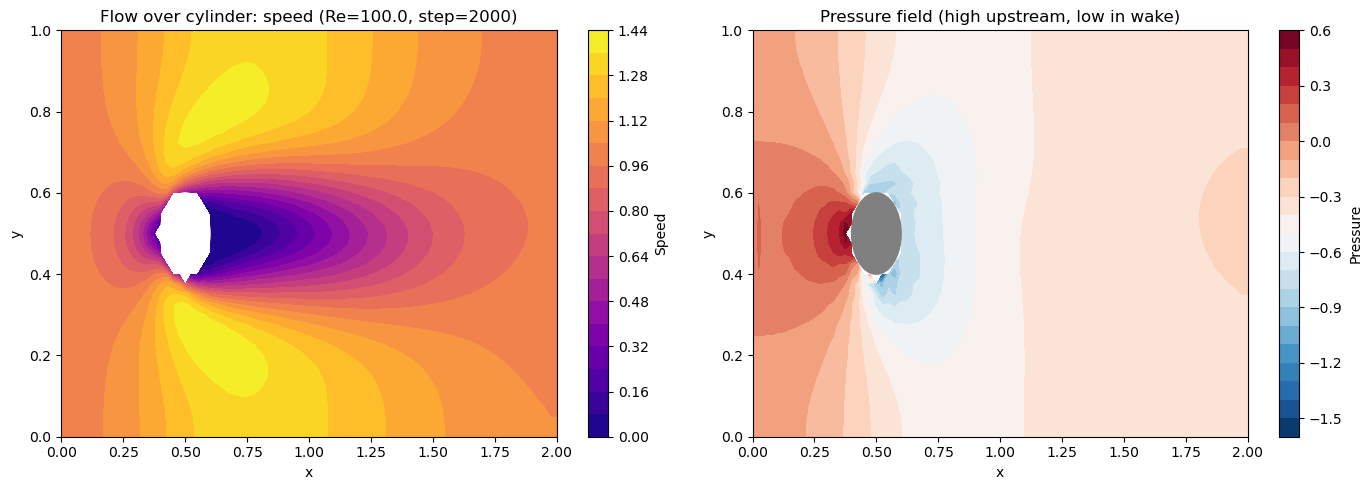

Notice: high pressure upstream (stagnation), low pressure in wake — this creates drag.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2D flow over a cylinder using immersed boundary (mask method)
# Cylinder centred at (cx, cy) with radius R

# Grid
ny, nx = 41, 81
Lx, Ly = 2.0, 1.0
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)
x  = np.linspace(0, Lx, nx)
y  = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# Cylinder
cx, cy = 0.5, 0.5
R = 0.1
cylinder_mask = (X - cx)**2 + (Y - cy)**2 <= R**2

# Flow parameters
Re  = 100.0
nu  = 1.0 / Re
rho = 1.0
U_in = 1.0
dt  = 0.0005

u = np.ones((ny, nx)) * U_in
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))

# Apply cylinder mask initially
u[cylinder_mask] = 0.0
v[cylinder_mask] = 0.0

def poisson_step(p, rhs, dx, dy, n=30):
    for _ in range(n):
        p[1:-1,1:-1] = (
            (p[1:-1,2:]+p[1:-1,:-2])/dx**2 +
            (p[2:,1:-1]+p[:-2,1:-1])/dy**2 -
            rhs[1:-1,1:-1]
        ) / (2/dx**2 + 2/dy**2)
        p[0,:]=p[1,:]; p[-1,:]=p[-2,:]  # walls
        p[:,0]=0;      p[:,-1]=p[:,-2]  # inlet p=0, outlet dp/dx=0
    return p

snapshots_u = []
snapshot_steps = set([0, 500, 1000, 2000])

for step in range(2001):
    un, vn = u.copy(), v.copy()

    # Build PPE RHS
    b = np.zeros_like(p)
    b[1:-1,1:-1] = rho/dt*((un[1:-1,2:]-un[1:-1,:-2])/(2*dx)
                           +(vn[2:,1:-1]-vn[:-2,1:-1])/(2*dy))
    p = poisson_step(p, b, dx, dy)

    # Momentum update
    def mom_update(phi, dphi, adv_x, adv_y, nu_term):
        return phi - dt*(adv_x + adv_y) - dt/rho*dphi + dt*nu*nu_term

    u[1:-1,1:-1] = mom_update(
        un[1:-1,1:-1],
        (p[1:-1,2:]-p[1:-1,:-2])/(2*dx),
        un[1:-1,1:-1]*(un[1:-1,1:-1]-un[1:-1,:-2])/dx,
        vn[1:-1,1:-1]*(un[1:-1,1:-1]-un[:-2,1:-1])/dy,
        (un[1:-1,2:]-2*un[1:-1,1:-1]+un[1:-1,:-2])/dx**2
        +(un[2:,1:-1]-2*un[1:-1,1:-1]+un[:-2,1:-1])/dy**2)

    v[1:-1,1:-1] = mom_update(
        vn[1:-1,1:-1],
        (p[2:,1:-1]-p[:-2,1:-1])/(2*dy),
        un[1:-1,1:-1]*(vn[1:-1,1:-1]-vn[1:-1,:-2])/dx,
        vn[1:-1,1:-1]*(vn[1:-1,1:-1]-vn[:-2,1:-1])/dy,
        (vn[1:-1,2:]-2*vn[1:-1,1:-1]+vn[1:-1,:-2])/dx**2
        +(vn[2:,1:-1]-2*vn[1:-1,1:-1]+vn[:-2,1:-1])/dy**2)

    # BCs: inlet, walls, outflow
    u[:,0] = U_in; v[:,0] = 0   # inlet
    u[:,-1]= u[:,-2]; v[:,-1]=v[:,-2]  # outflow
    u[0,:] = u[1,:];  v[0,:] = 0  # bottom wall
    u[-1,:] = u[-2,:]; v[-1,:] = 0  # top wall

    # Enforce no-slip on cylinder
    u[cylinder_mask] = 0.0
    v[cylinder_mask] = 0.0

    if step in snapshot_steps:
        snapshots_u.append((step, u.copy(), v.copy(), p.copy()))

# Visualize final state
_, u_final, v_final, p_final = snapshots_u[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed contour + streamlines
speed = np.sqrt(u_final**2 + v_final**2)
speed[cylinder_mask] = np.nan
cf = axes[0].contourf(X, Y, speed, levels=20, cmap='plasma')
plt.colorbar(cf, ax=axes[0], label='Speed')
circle = plt.Circle((cx, cy), R, color='white', zorder=5)
axes[0].add_patch(circle)
axes[0].set_title(f'Flow over cylinder: speed (Re={Re}, step=2000)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_xlim(0, Lx); axes[0].set_ylim(0, Ly)

# Pressure
p_plot = p_final.copy()
p_plot[cylinder_mask] = np.nan
cf2 = axes[1].contourf(X, Y, p_plot, levels=20, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[1], label='Pressure')
circle2 = plt.Circle((cx, cy), R, color='gray', zorder=5)
axes[1].add_patch(circle2)
axes[1].set_title('Pressure field (high upstream, low in wake)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_xlim(0, Lx); axes[1].set_ylim(0, Ly)

plt.tight_layout()
plt.show()

print("Notice: high pressure upstream (stagnation), low pressure in wake — this creates drag.")

## Key Takeaways

- The Kármán vortex street develops when Re > ~47 for flow past a cylinder.
- The Strouhal number $St \approx 0.2$ characterises the shedding frequency.
- Drag has two components: pressure drag (form drag) and viscous drag (skin friction).
- At high Re, pressure drag dominates — this is why streamlined shapes reduce drag.
- The immersed boundary method allows Cartesian grids for complex geometries.

---

**Next**: Lesson 2.8 — Boundary Conditions: Dirichlet, Neumann, periodic, inlet/outlet, ghost cells.
